In [114]:
from datetime import datetime, time
import pandas as pd
import numpy as np

from Strategies.Sparse_momentum.ob_attributes import OB_attributes
from Strategies.Sparse_momentum.ob_attributes import diff, unify_time_pd
from OrderBook.OrderBook import OrderBookSnaps
from SynthSpread.spreadviewer_class import SpreadSingle
from Database.TPData import TPData, TPDataDa

In [111]:
def product_dates(dates, t, tn, n_s):
    # Product dates
    pd_list = [dates.shift(1, freq='B') if t == 'da' else
                dates.shift(tn, freq='W-MON') if t == 'w' else
                dates.shift(tn, freq='YS') if t == 'dec' else
                (dates + n_s * dates.freq).shift(tn, freq='AS-Apr') if t in ['sum'] else
                (dates + n_s * dates.freq).shift(tn, freq='AS-Oct') if t in ['win'] else
                (dates + n_s * dates.freq).shift(tn, freq=t.upper() + 'S')]
    return pd_list

def get_index_for_ts(series, ts):
    idx_cand = (series - ts).abs().idxmin()
    while series[idx_cand] < ts:
        idx_cand += 1
        if idx_cand > len(series)-1:
            return len(series)-1
    return idx_cand

In [115]:
n_s = 2
# mkt_list = ['de', 'de', 'de']
primary_mkt = {
    'mkt': 'de',
    'tenor': 'm',
    'tn1': 1
}
secondary_mkts = [
    {'mkt': 'de', 'tenor': 'q', 'tn1': 1},
    {'mkt': 'de', 'tenor': 'y', 'tn1': 1},
    {'mkt': 'ttf', 'tenor': 'm', 'tn1': 1}
]


prod = 'base'
venue_list = ['eex']
# Order book features variables
features_list = ['ba_volrat', 'mid_priceW', 'sparsity', 'p_movement']
depth_list = [0.5]
tick = 0.01
tick_val = 200
cls_margin = 0.10
obAtt = OB_attributes(features_list)
#   -   -   - 
start_date = datetime(2024, 4, 15)
end_date = datetime(2024, 4, 15)
dates = pd.date_range(start_date, end_date, freq='B')

primary_mkt['pd'] = product_dates(dates, primary_mkt['tenor'], primary_mkt['tn1'], n_s)
_ = [sec_m.update({'pd': product_dates(dates, sec_m['tenor'], sec_m['tn1'], n_s)}) for sec_m in secondary_mkts]


start_time = time(9, 0, 0, 0)
end_time = time(17, 25, 0, 0)

data_class = TPDataDa()
trades_df = pd.DataFrame()
for ds, pd1 in zip(dates, *primary_mkt['pd']):
    try:
        bT = datetime.combine(ds, start_time)
        eT = datetime.combine(ds, end_time)
        ob_class = OrderBookSnaps(verbose=True)

        trades = data_class.get_trades(primary_mkt['mkt'], primary_mkt['tenor'], venue_list, pd1, bT, eT, prod)
        df_ord_data = data_class.get_orders_data(primary_mkt['mkt'], primary_mkt['tenor'], venue_list, pd1,
                                            bT, eT, prod, None)
        ob_class.import_from_tp(df_ord_data)

        data_dict = obAtt.prepare_ob_data(ob_class.LoB_dict, depth_list)
        idx, csum = obAtt.calc_tick_index(data_dict, None, None, 1, tick=tick)
        class_ser = obAtt.prepare_class_data(data_dict, csum, idx,
                                                tick_val, cls_margin)
        df_current = pd.DataFrame(data_dict).set_index('timestamp')
        df_current['y'] = class_ser['class']
        df_current.reset_index(inplace=True)
        for trade in trades.reset_index().to_dict(orient='records'):
            ts = trade['datetime']
            index = get_index_for_ts(pd.Series(ob_class.time_list), ts)
            df_current.loc[index, 'trd_price'] = trade['price']
            df_current.loc[index, 'trd_vol'] = trade['volume']
            df_current.loc[index, 'trd_side'] = 0 if abs(df_current.loc[index, 'b_price'] - trade['price']) <  abs(df_current.loc[index, 'a_price'] - trade['price']) else 1
        
        df_current['last_trd_p'] = df_current['trd_price']
        df_current['last_trd_p'].ffill(inplace=True)
        df_current['bid_t1'] = df_current['b_price'].shift(-1) == df_current['b_price']
        df_current['ask_t1'] = df_current['a_price'].shift(-1) == df_current['a_price']
        
        if df_data.empty:
            df_data = df_current.copy()
        else:
            df_data = pd.concat([df_data, df_current])
    except Exception as e:
        print(e)
        pass
sec_dict = {}
for mkt_dict in secondary_mkts:
    current_df = pd.DataFrame()
    for ds, pd1 in zip(dates, *mkt_dict['pd']):
        # try:
        bT = datetime.combine(ds, start_time)
        eT = datetime.combine(ds, end_time)
        
        trades = data_class.get_trades(mkt_dict['mkt'], mkt_dict['tenor'], venue_list, pd1, bT, eT, prod)
        if current_df.empty:
            current_df = trades
        else:
            current_df = pd.concat([current_df, trades])
        # except Exception as e:
        #     print(e)
        #     pass
    sec_dict[f"{mkt_dict['mkt']}_{mkt_dict['tenor']}"] = current_df

for sec_mkt, df in sec_dict.items():
    col_name = f"diff_{sec_mkt}"
    df = df[~df.index.duplicated()]
    diff_series = diff(df['price'], 5, True)
    for ts, price in diff_series.to_dict().items():
        index = get_index_for_ts(df_data['timestamp'], ts)
        df_data.loc[index, col_name] = price
    df_data[col_name].ffill(inplace=True)

https://referencedata.trayport.com/instruments
Duration: 0.576s
https://analytics.trayport.com/api/trades?from=2024-04-15T07%3A00%3A00Z&until=2024-04-15T15%3A25%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=245&ContractType=SinglePeriod
Duration: 2.477s
https://referencedata.trayport.com/instruments
Duration: 0.575s
https://analytics.trayport.com/api/orders/book?from=2024-04-15T07%3A00%3A00Z&until=2024-04-15T15%3A25%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=245&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 8.601s


X:\Strategies\Sparse_momentum\ob_attributes.py:418: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bid_series.fillna(method='ffill', inplace=True)
X:\Strategies\Sparse_momentum\ob_attributes.py:436: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ask_series.fillna(method='ffill', inplace=True)
X:\Strategies\Sparse_momentum\ob_attributes.py:453: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bid_series.fillna(method='ffill', inplace=True)
X:\Strategies\Sparse_momentum\ob_attributes.py:457: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ask_series.fillna(method='ffill', inplace=True)
X:\Strategies\Sparse_momentum\ob_attributes.py:511: FutureWa

https://referencedata.trayport.com/instruments
Duration: 0.560s
https://analytics.trayport.com/api/trades?from=2024-04-15T07%3A00%3A00Z&until=2024-04-15T15%3A25%3A00Z&instrumentId=10641710&sequenceId=10000105&sequenceItemId=83&ContractType=SinglePeriod
Duration: 1.639s
https://referencedata.trayport.com/instruments
Duration: 0.590s
https://analytics.trayport.com/api/trades?from=2024-04-15T07%3A00%3A00Z&until=2024-04-15T15%3A25%3A00Z&instrumentId=10641710&sequenceId=10000106&sequenceItemId=22&ContractType=SinglePeriod
Duration: 1.613s
https://referencedata.trayport.com/instruments
Duration: 0.565s
https://analytics.trayport.com/api/trades?from=2024-04-15T07%3A00%3A00Z&until=2024-04-15T15%3A25%3A00Z&instrumentId=10002806&sequenceId=10000305&sequenceItemId=245&ContractType=SinglePeriod
Duration: 0.651s


X:\Strategies\Sparse_momentum\ob_attributes.py:511: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  value0 = data_series.fillna(method='bfill').iloc[0]
X:\Strategies\Sparse_momentum\ob_attributes.py:511: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  value0 = data_series.fillna(method='bfill').iloc[0]
X:\Strategies\Sparse_momentum\ob_attributes.py:511: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  value0 = data_series.fillna(method='bfill').iloc[0]


In [116]:
df_data

,timestamp,ba_spread,b_price,a_price,mid_price,ba_volrat_0.5,mid_priceW_0.5,b_price_sparsity,a_price_sparsity,p_movement,y,trd_price,trd_vol,trd_side,last_trd_p,bid_t1,ask_t1,diff_de_q,diff_de_y,diff_ttf_m
0,2024-04-15 09:00:00,0.002041,63.62,63.75,63.685,0.000000,0.000000e+00,0.05,0.20,-0.000000,1.0,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN
1,2024-04-15 09:00:01,0.002042,63.61,63.74,63.675,-0.333333,2.166667e-02,0.11,0.13,-0.001111,1.0,63.62,1.0,0.0,63.62,False,False,NaN,NaN,NaN
2,2024-04-15 09:00:02,0.003139,63.62,63.82,63.720,0.500000,-5.000000e-02,0.07,0.10,0.013611,1.0,63.75,1.0,1.0,63.75,True,False,NaN,NaN,NaN
3,2024-04-15 09:00:03,0.003765,63.62,63.86,63.740,0.200000,-2.400000e-02,0.07,0.12,0.033611,1.0,NaN,NaN,NaN,63.75,True,True,NaN,NaN,NaN
4,2024-04-15 09:00:04,0.003765,63.62,63.86,63.740,0.200000,-2.400000e-02,0.07,0.10,0.033611,1.0,NaN,NaN,NaN,63.75,True,True,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17469,2024-04-15 17:24:54,0.002564,66.21,66.38,66.295,0.000000,1.421085e-14,0.15,0.09,0.302500,NaN,NaN,NaN,NaN,66.37,True,True,0.003897,-0.000551,0.002986
17470,2024-04-15 17:24:55,0.002564,66.21,66.38,66.295,-0.200000,1.700000e-02,0.15,0.09,0.302500,NaN,NaN,NaN,NaN,66.37,True,False,0.003897,-0.000551,0.002986
17471,2024-04-15 17:24:56,0.001811,66.21,66.33,66.270,0.200000,-1.200000e-02,0.15,0.07,0.217778,NaN,NaN,NaN,NaN,66.37,True,True,0.003897,-0.000551,0.002986
17472,2024-04-15 17:24:57,0.001811,66.21,66.33,66.270,-0.333333,2.000000e-02,0.08,0.07,0.217778,NaN,NaN,NaN,NaN,66.37,True,True,0.003897,-0.000551,0.002986


X:\Strategies\Sparse_momentum\ob_attributes.py:511: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  value0 = data_series.fillna(method='bfill').iloc[0]
X:\Strategies\Sparse_momentum\ob_attributes.py:511: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  value0 = data_series.fillna(method='bfill').iloc[0]
X:\Strategies\Sparse_momentum\ob_attributes.py:511: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  value0 = data_series.fillna(method='bfill').iloc[0]


<Axes: >

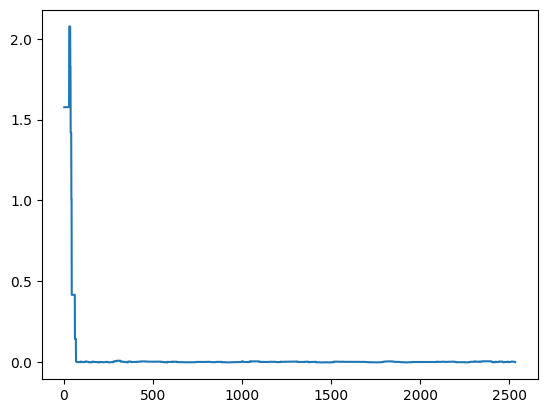